In [1]:
import pandas as pd
data = pd.read_csv('Road_accident_data.csv')
print(f'Over dataSet is \n{data.head()}')

Over dataSet is 
       Time Day_of_week Age_band_of_driver Sex_of_driver   Educational_level  \
0  17:02:00      Monday              18-30          Male   Above high school   
1  17:02:00      Monday              31-50          Male  Junior high school   
2  17:02:00      Monday              18-30          Male  Junior high school   
3  01:06:00      Sunday              18-30          Male  Junior high school   
4  01:06:00      Sunday              18-30          Male  Junior high school   

  Vehicle_driver_relation Driving_experience      Type_of_vehicle  \
0                Employee              1-2yr           Automobile   
1                Employee         Above 10yr  Public (> 45 seats)   
2                Employee              1-2yr      Lorry (41?100Q)   
3                Employee             5-10yr  Public (> 45 seats)   
4                Employee              2-5yr                  NaN   

  Owner_of_vehicle Service_year_of_vehicle  ... Vehicle_movement  \
0            Owner 

In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            11575 non-null  object
 5   Vehicle_driver_relation      11737 non-null  object
 6   Driving_experience           11487 non-null  object
 7   Type_of_vehicle              11366 non-null  object
 8   Owner_of_vehicle             11834 non-null  object
 9   Service_year_of_vehicle      8388 non-null   object
 10  Defect_of_vehicle            7889 non-null   object
 11  Area_accident_occured        12077 non-null  object
 12  Lanes_or_Medians             11931 non-null  object
 13  Road_allignment              12

In [3]:
data.columns

Index(['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver',
       'Educational_level', 'Vehicle_driver_relation', 'Driving_experience',
       'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle',
       'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians',
       'Road_allignment', 'Types_of_Junction', 'Road_surface_type',
       'Road_surface_conditions', 'Light_conditions', 'Weather_conditions',
       'Type_of_collision', 'Number_of_vehicles_involved',
       'Number_of_casualties', 'Vehicle_movement', 'Casualty_class',
       'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity',
       'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement',
       'Cause_of_accident', 'Accident_severity'],
      dtype='object')

In [4]:
data.shape

(12316, 32)

In [5]:
data.describe()

,Number_of_vehicles_involved,Number_of_casualties
count,12316.000000,12316.000000
mean,2.040679,1.548149
std,0.688790,1.007179
min,1.000000,1.000000
25%,2.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,2.000000
max,7.000000,8.000000


In [6]:
data.isna().sum().sort_values(ascending =  False)

Defect_of_vehicle              4427
Service_year_of_vehicle        3928
Work_of_casuality              3198
Fitness_of_casuality           2635
Type_of_vehicle                 950
Types_of_Junction               887
Driving_experience              829
Educational_level               741
Vehicle_driver_relation         579
Owner_of_vehicle                482
Lanes_or_Medians                385
Vehicle_movement                308
Area_accident_occured           239
Road_surface_type               172
Type_of_collision               155
Road_allignment                 142
Sex_of_driver                     0
Age_band_of_driver                0
Day_of_week                       0
Time                              0
Weather_conditions                0
Number_of_vehicles_involved       0
Light_conditions                  0
Road_surface_conditions           0
Casualty_class                    0
Number_of_casualties              0
Age_band_of_casualty              0
Sex_of_casualty             

In [7]:
for col in ['Area_accident_occured','Accident_severity','Weather_conditions']:
    print("-"*40)
    print(col)
    print(data[col].nunique())
    print(data[col].unique()[:10])

----------------------------------------
Area_accident_occured
14
['Residential areas' 'Office areas' '  Recreational areas'
 ' Industrial areas' nan 'Other' ' Church areas' '  Market areas'
 'Unknown' 'Rural village areas']
----------------------------------------
Accident_severity
3
['Slight Injury' 'Serious Injury' 'Fatal injury']
----------------------------------------
Weather_conditions
9
['Normal' 'Raining' 'Raining and Windy' 'Cloudy' 'Other' 'Windy' 'Snow'
 'Unknown' 'Fog or mist']


## Cleaning & standardization

- Trim strings, lower/normalize, convert common bad tokens ('', 'Unknown', 'NA', 'N/A', '-') → pd.NA.

- Convert numeric columns to int (fill zeros where needed).

- Parse Time into datetime.time or create Hour.

- Add Accident_ID index.

- Remove duplicates.

In [9]:
df = data.copy()

In [12]:
import numpy as np

In [13]:
df = df.replace('na' , np.nan)

In [14]:
#  Droping columns with more than 40% missing values

threshold = 0.4*len(df)  
df = df.dropna(thresh=threshold, axis =1)

In [15]:
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna("Unknown")
    else:
        df[col] = df[col].fillna(df[col].median())

In [18]:
df['Hour'] = pd.to_datetime(df['Time'], format="%H:%M:%S", errors='coerce').dt.hour

df['Hour'] = df['Hour'].fillna(df['Hour'].median()).astype(int)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            12316 non-null  object
 5   Vehicle_driver_relation      12316 non-null  object
 6   Driving_experience           12316 non-null  object
 7   Type_of_vehicle              12316 non-null  object
 8   Owner_of_vehicle             12316 non-null  object
 9   Service_year_of_vehicle      12316 non-null  object
 10  Defect_of_vehicle            12316 non-null  object
 11  Area_accident_occured        12316 non-null  object
 12  Lanes_or_Medians             12316 non-null  object
 13  Road_allignment              12

In [22]:
print("Total Missing Values After Cleaning:", df.isna().sum().sum())
print("-"*20)
print(df.head())

Total Missing Values After Cleaning: 0
--------------------
       Time Day_of_week Age_band_of_driver Sex_of_driver   Educational_level  \
0  17:02:00      Monday              18-30          Male   Above high school   
1  17:02:00      Monday              31-50          Male  Junior high school   
2  17:02:00      Monday              18-30          Male  Junior high school   
3  01:06:00      Sunday              18-30          Male  Junior high school   
4  01:06:00      Sunday              18-30          Male  Junior high school   

  Vehicle_driver_relation Driving_experience      Type_of_vehicle  \
0                Employee              1-2yr           Automobile   
1                Employee         Above 10yr  Public (> 45 seats)   
2                Employee              1-2yr      Lorry (41?100Q)   
3                Employee             5-10yr  Public (> 45 seats)   
4                Employee              2-5yr              Unknown   

  Owner_of_vehicle Service_year_of_vehicle  

In [21]:
df.isna().sum().sort_values(ascending =  False)

Time                           0
Day_of_week                    0
Age_band_of_driver             0
Sex_of_driver                  0
Educational_level              0
Vehicle_driver_relation        0
Driving_experience             0
Type_of_vehicle                0
Owner_of_vehicle               0
Service_year_of_vehicle        0
Defect_of_vehicle              0
Area_accident_occured          0
Lanes_or_Medians               0
Road_allignment                0
Types_of_Junction              0
Road_surface_type              0
Road_surface_conditions        0
Light_conditions               0
Weather_conditions             0
Type_of_collision              0
Number_of_vehicles_involved    0
Number_of_casualties           0
Vehicle_movement               0
Casualty_class                 0
Sex_of_casualty                0
Age_band_of_casualty           0
Casualty_severity              0
Work_of_casuality              0
Fitness_of_casuality           0
Pedestrian_movement            0
Cause_of_a

# Visualizations

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
sns.set(style = 'whitegrid' , palette = 'pastel' , font_scale =1.1)

- figure 1. Accident Severity Distribution

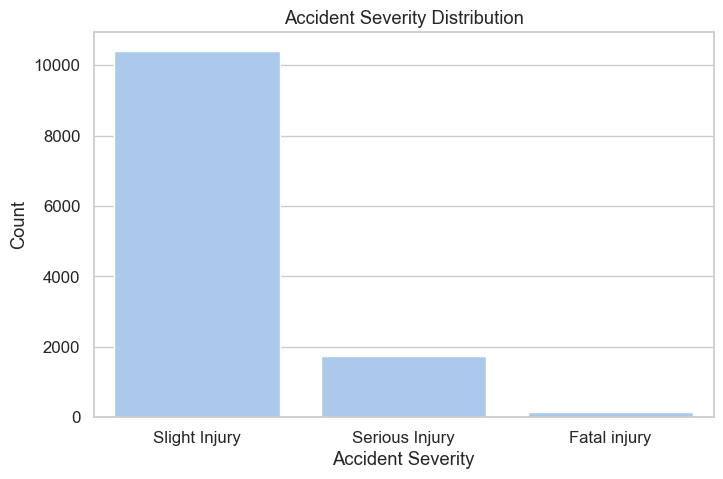

In [25]:
plt.figure(figsize=(8,5))
sns.countplot(
    data = df,
    x = 'Accident_severity',
    order = df['Accident_severity'].value_counts().index
)
plt.title('Accident Severity Distribution')
plt.xlabel('Accident Severity')
plt.ylabel('Count')
plt.show()


- Figure 2. Accidents by Hour of Day

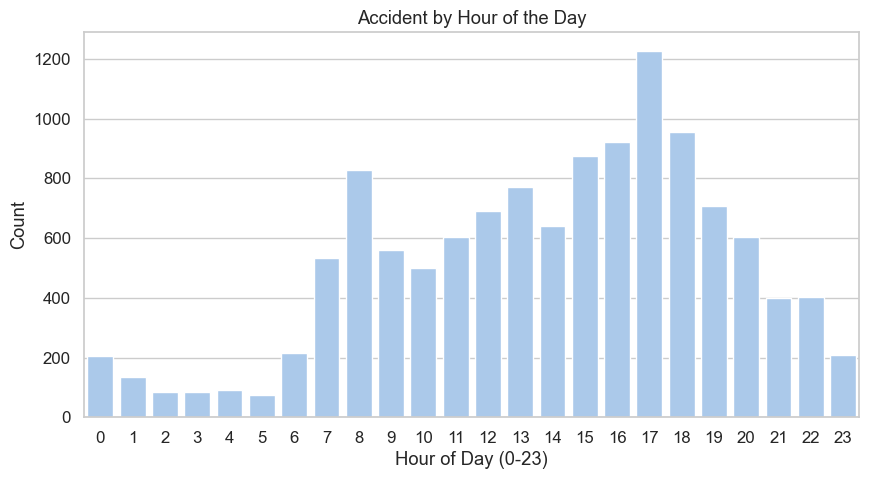

In [26]:
plt.figure(figsize=(10,5))
sns.countplot(
    data = df,
    x = 'Hour'
)
plt.title('Accident by Hour of the Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Count')
plt.show()

- Figure 3. Accidents by Day of the Week

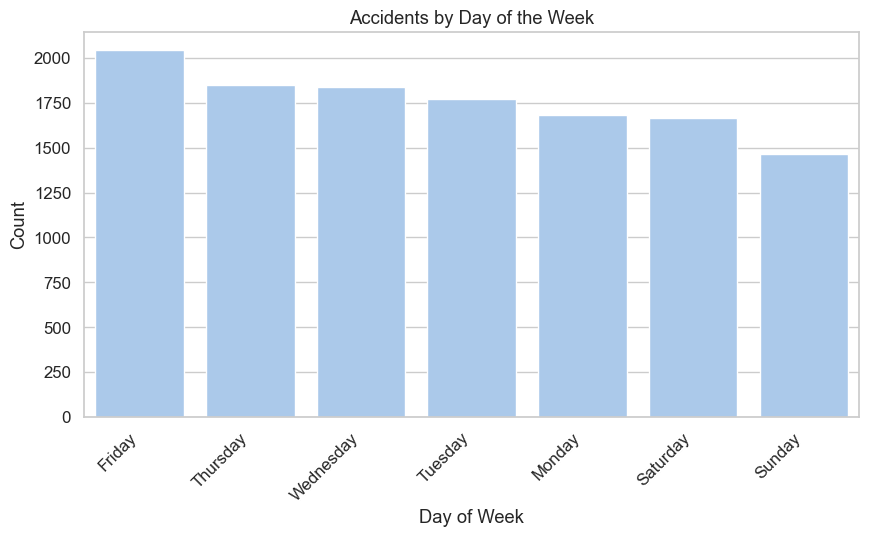

In [30]:
plt.figure(figsize = (10,5))
sns.countplot(
    data = df,
    x = 'Day_of_week',
    order = df['Day_of_week'].value_counts().index
)
plt.title('Accidents by Day of the Week')
plt.xlabel('Day of Week')
plt.xticks(rotation = 45 , ha = 'right')
plt.ylabel('Count')
plt.show()

- Figure  4. Top 10 Causes of Accident

In [38]:
top_causes = df['Cause_of_accident'].value_counts().head(10)

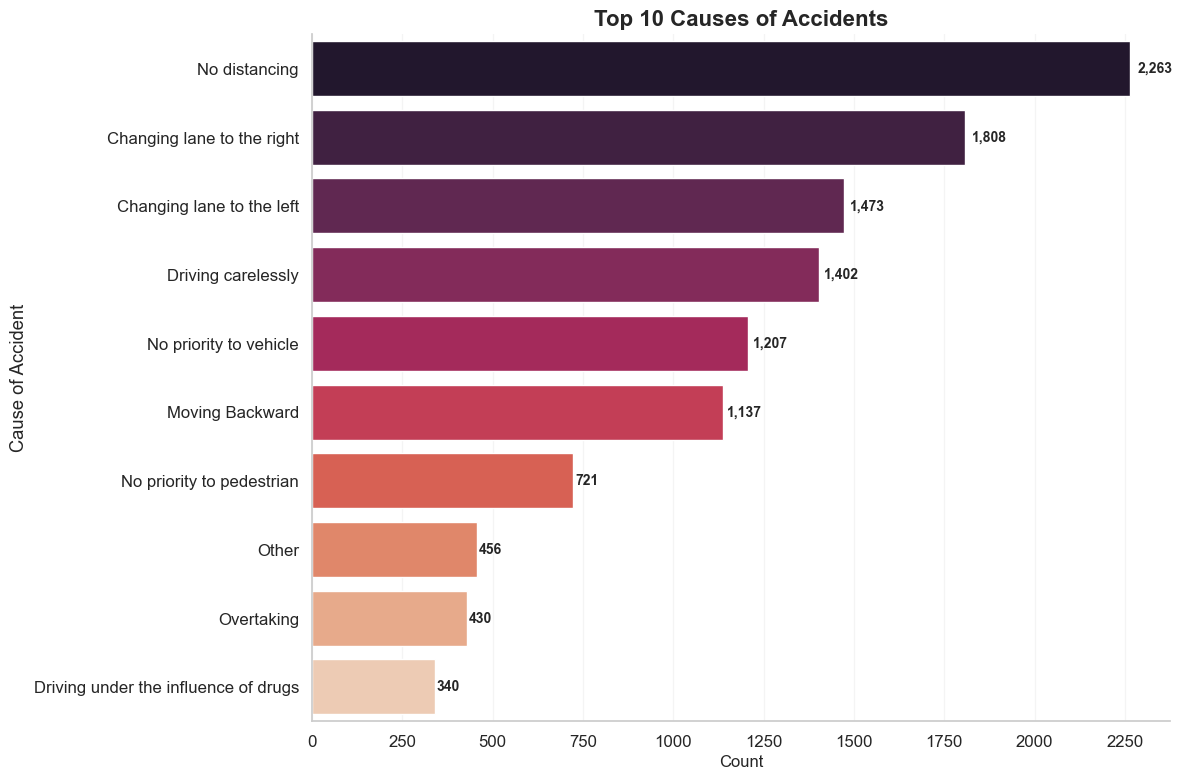

In [43]:
from matplotlib.ticker import MultipleLocator , FuncFormatter

plt.figure(figsize = (12, 8))
ax = sns.barplot(
    x = top_causes.values,
    y = top_causes.index,
    palette='rocket',
    hue = top_causes.index
)
ax.xaxis.set_major_locator(plt.MaxNLocator(10))

for i , v in enumerate(top_causes.values):
    ax.text(v + v * 0.01,
            i, f'{v:,}',
            va = 'center',
            ha = 'left',
            fontsize = 10,
            fontweight = 'bold'
           )

plt.title('Top 10 Causes of Accidents', fontsize=16, fontweight='bold')
plt.xlabel('Count', fontsize=12)
plt.ylabel('Cause of Accident')
plt.grid(axis='x', alpha=0.2)
sns.despine()
plt.tight_layout()
plt.show()

- Figure 5 : Accident Severity by Driver Age Band

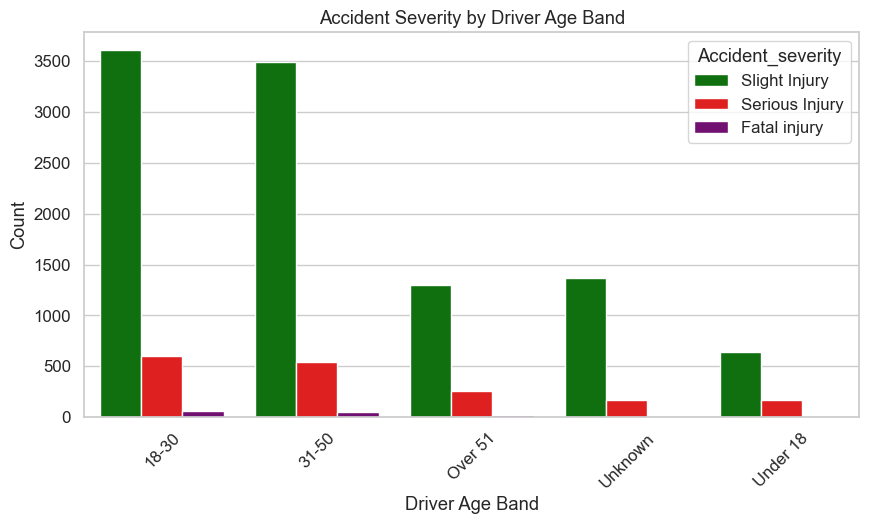

In [48]:
severity_palette = {
    'Slight Injury': 'green',     
    'Serious Injury': 'red',       
    'Fatal injury': 'purple',
}

plt.figure(figsize = (10,5))
sns.countplot(
    data = df,
    x = 'Age_band_of_driver',
    hue = 'Accident_severity',
    order = df['Age_band_of_driver'].value_counts().index,
    palette=severity_palette
)
plt.title('Accident Severity by Driver Age Band')
plt.xlabel('Driver Age Band')
plt.ylabel('Count')
plt.xticks(rotation = 45)
plt.show()

- Figure 6 : Accident Severity by Driver Sex

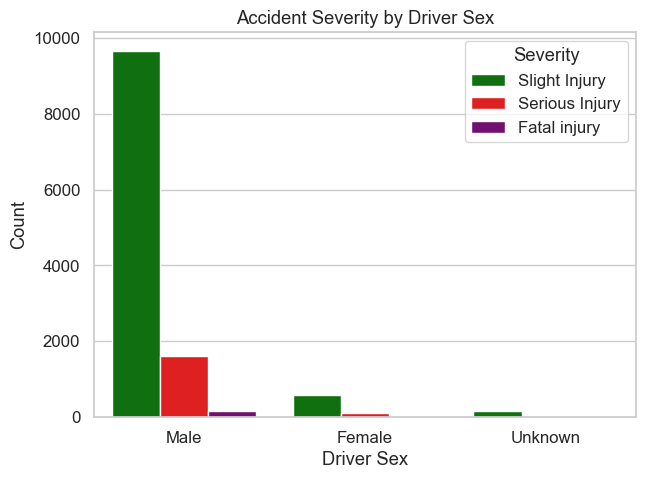

In [50]:
plt.figure(figsize = (7,5))
sns.countplot(
    data = df,
    x = 'Sex_of_driver',
    hue = 'Accident_severity',
    order = df['Sex_of_driver'].value_counts().index,
    palette=severity_palette
)
plt.title("Accident Severity by Driver Sex")
plt.xlabel("Driver Sex")
plt.ylabel("Count")
plt.legend(title="Severity")
plt.show()

- Figure 7 : Accident Severity by Driving Experience

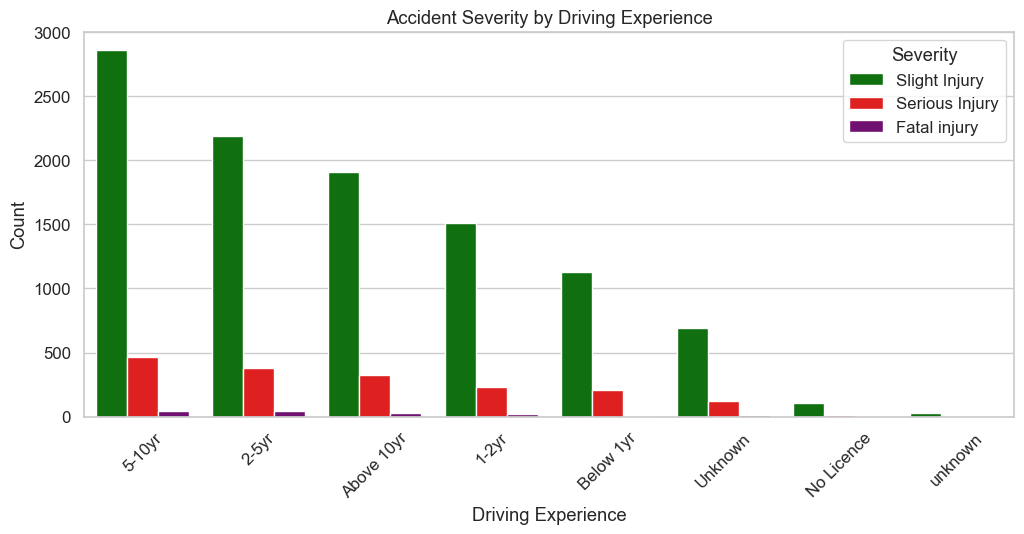

In [52]:
plt.figure(figsize = (12,5))
sns.countplot(
    x =  df['Driving_experience'],
    hue = df['Accident_severity'],
    order = df['Driving_experience'].value_counts().index,
    palette=severity_palette,
)
plt.title('Accident Severity by Driving Experience')
plt.xlabel('Driving Experience')
plt.ylabel('Count')
plt.legend(title = 'Severity')
plt.xticks(rotation = 45)
plt.show()

- Figure 8 : Accident Severity by Type of Vehicle

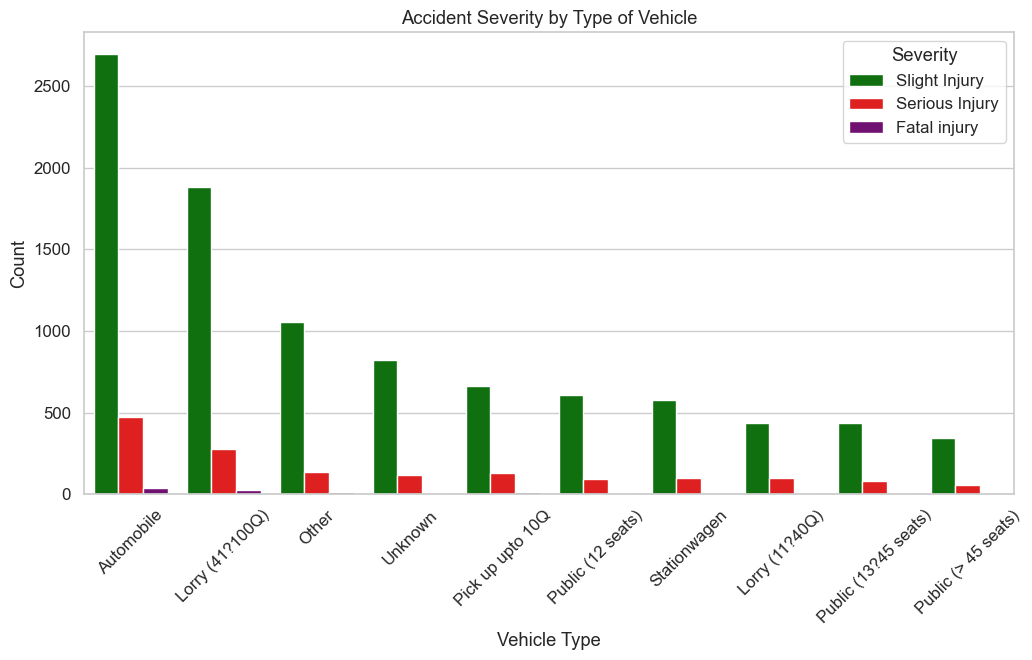

In [55]:
plt.figure(figsize = (12,6))
sns.countplot(
    x = df['Type_of_vehicle'],
    hue = df['Accident_severity'],
    order= df['Type_of_vehicle'].value_counts().index[:10],
    palette=severity_palette,
)
plt.title('Accident Severity by Type of Vehicle')
plt.xlabel('Vehicle Type')
plt.ylabel('Count')
plt.legend(title = 'Severity')
plt.xticks(rotation = 45)
plt.show()

- Figure 9 : Accident Severity by Weather Conditions

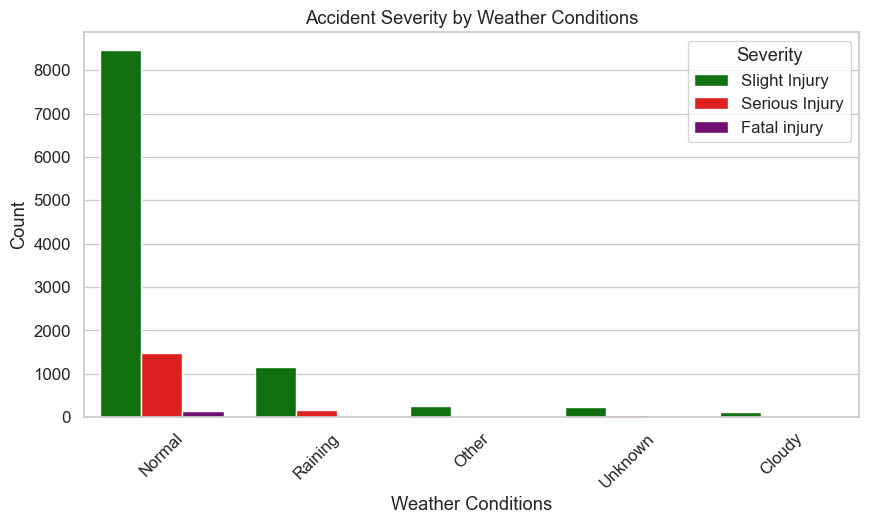

In [58]:
plt.figure(figsize = (10,5))
sns.countplot(
    x = df['Weather_conditions'],
    hue = df['Accident_severity'],
    palette= severity_palette,
    order= df['Weather_conditions'].value_counts().index[:5]
)
plt.title('Accident Severity by Weather Conditions')
plt.xlabel('Weather Conditions')
plt.ylabel('Count')
plt.legend(title = 'Severity')
plt.xticks(rotation = 45)
plt.show()

- Figure 10 : Accident Severity by Road Surface Type

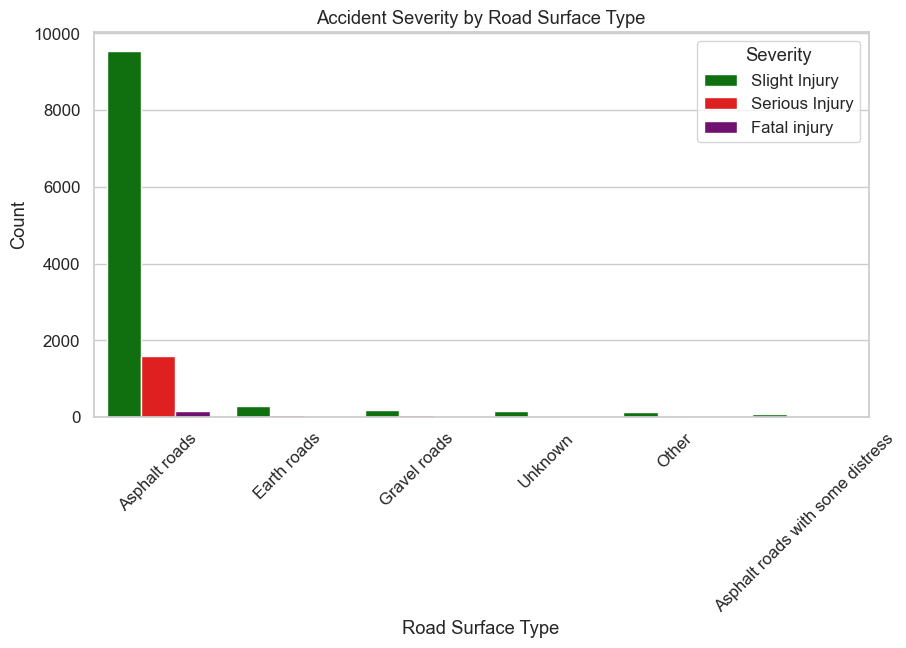

In [59]:
plt.figure(figsize = (10,5))
sns.countplot(
    x = df['Road_surface_type'],
    hue = df['Accident_severity'],
    order= df['Road_surface_type'].value_counts().index,
    palette = severity_palette
)
plt.title('Accident Severity by Road Surface Type')
plt.xlabel('Road Surface Type')
plt.ylabel('Count')
plt.legend(title="Severity")
plt.xticks(rotation=45)
plt.show()

- Figure 11 : Accident Severity by Types of Junction

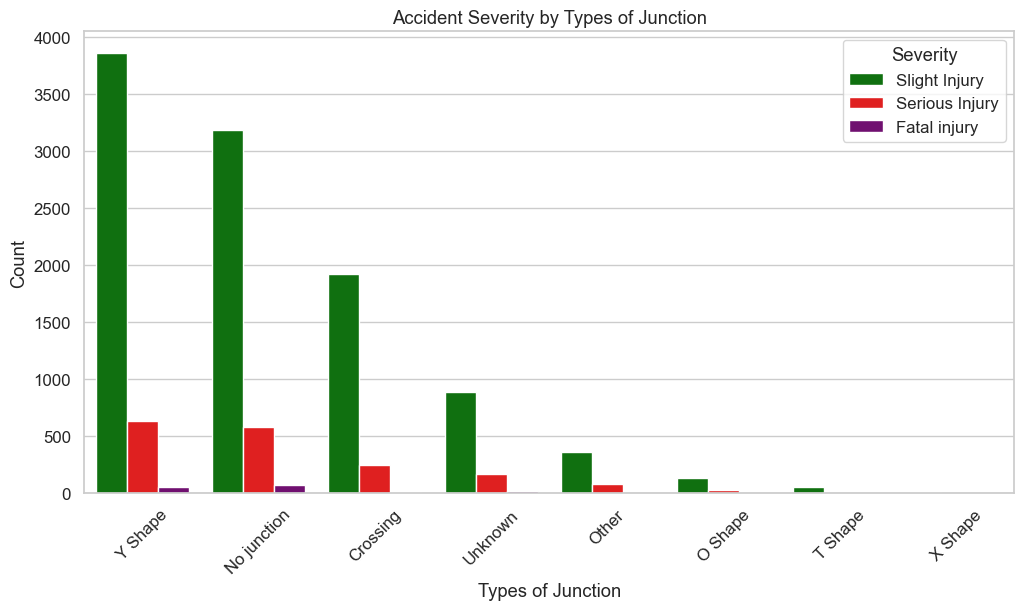

In [61]:
plt.figure(figsize = (12,6))
sns.countplot(
    x = df['Types_of_Junction'],
    hue = df['Accident_severity'],
    palette = severity_palette,
    order= df['Types_of_Junction'].value_counts().index[:10]
)
plt.title('Accident Severity by Types of Junction')
plt.xlabel("Types of Junction")
plt.ylabel("Count")
plt.legend(title="Severity")
plt.xticks(rotation=45)
plt.show()

- Figure 12 : Correlation Heatmap for numeric variables

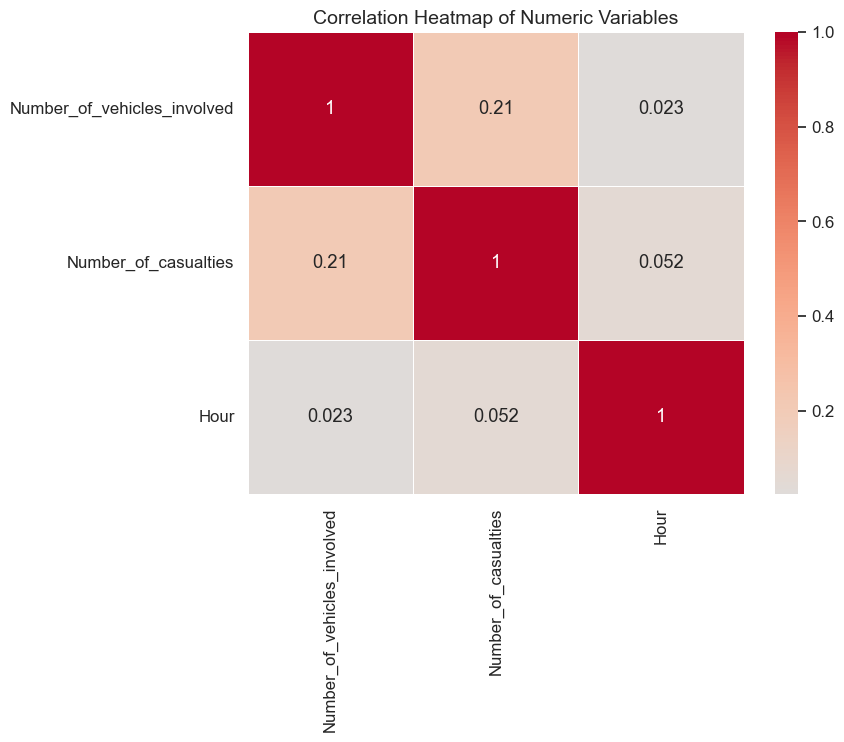

In [62]:
plt.figure(figsize=(8,6))
numeric_df = df[['Number_of_vehicles_involved','Number_of_casualties','Hour']]

corr = numeric_df.corr()
sns.heatmap(
    corr,
    annot=True,
    cmap = 'coolwarm',
    center = 0,
    linewidths = 0.5
)
plt.title("Correlation Heatmap of Numeric Variables", fontsize=14)
plt.show()

- Figure 13 : Number of Vehicles Involved vs Accident Severity

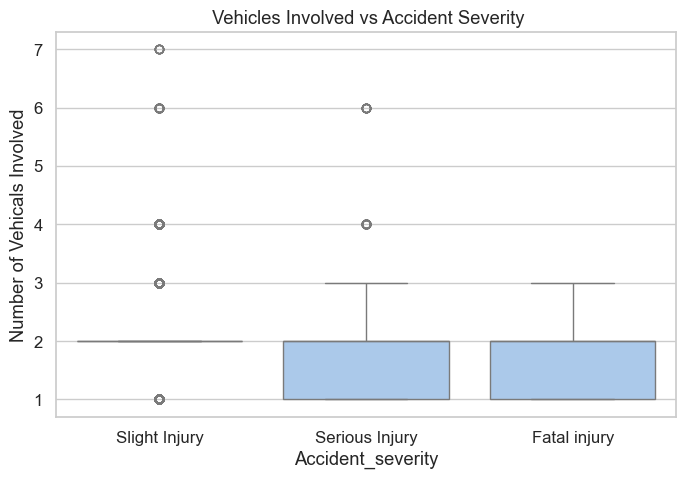

In [64]:
plt.figure(figsize =(8,5))
sns.boxplot(
    x = df['Accident_severity'],
    y = df['Number_of_vehicles_involved']
)
plt.title(' Vehicles Involved vs Accident Severity')
plt.xlabel('Accident_severity')
plt.ylabel('Number of Vehicals Involved')
plt.show()

- Figure 14 : Number of Casualties v/s Accident Severity

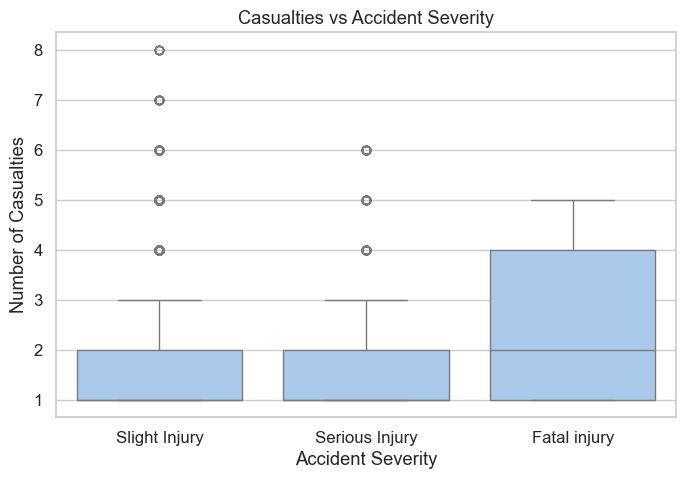

In [65]:
plt.figure(figsize = (8,5))
sns.boxplot(
    x = df['Accident_severity'],
    y = df['Number_of_casualties']
)
plt.title("Casualties vs Accident Severity")
plt.xlabel("Accident Severity")
plt.ylabel("Number of Casualties")
plt.show()